## 1. Setup & Imports

# Phage-Host Interaction Dataset for Machine Learning

This notebook demonstrates how to create machine learning datasets from the PBI database for phage-host interaction prediction.

## Contents
1. Setup & Imports
2. Connect to PBI Database
3. Query Phage-Host Pairs
4. Exploratory Data Analysis
5. Feature Engineering
6. Generate Negative Examples
7. Create Balanced Dataset
8. Save Datasets
9. Baseline ML Model
10. Next Steps

In [1]:
# Standard library
import sys
from pathlib import Path

# Add parent directory to path to import pbi
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PBI package
from pbi import quick_connect, SequenceRetriever, NegativeExampleGenerator

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("✅ Imports complete")

✅ Imports complete


## 2. Connect to PBI Database

The `quick_connect()` function automatically connects to the default database with all sequence files (phages, proteins, and hosts).

In [2]:
# Connect to database
retriever = quick_connect()


2026-02-20 07:59:00,392 - INFO - 📂 Checking FASTA index files:
2026-02-20 07:59:00,393 - INFO -    Phage index: True (52570.4 KB)
2026-02-20 07:59:00,394 - INFO -    Protein index: True (1432185.2 KB)
2026-02-20 07:59:00,396 - INFO - 📂 Using host mapping file: /data/processed/sequences/host_fasta_mapping.json
2026-02-20 07:59:00,401 - INFO -    Loaded mapping for 5525 hosts
2026-02-20 07:59:00,402 - INFO - 📂 Connecting to database: /data/processed/databases/phage_database_optimized.duckdb
2026-02-20 07:59:00,433 - INFO - 🔄 Starting background FASTA loading...
2026-02-20 07:59:00,434 - INFO - 🔄 [Background] Loading phage FASTA: /data/processed/sequences/all_phages.fasta
2026-02-20 07:59:00,435 - INFO - ✅ Initialization complete (FASTA loading in background)


In [3]:
# Get database statistics
stats = retriever.get_stats()

print("📊 Database Statistics:")
print(f"  Phage Stats: {stats['database']}")
print(f"  Phages in DB: {stats['database']['phages']:,}")
print(f"  Proteins in DB: {stats['database']['proteins']:,}")
print(f"  Hosts in DB: {stats['database']['hosts']:,}")
print(f"  Phage-Host Associations: {stats['database']['phage_host_associations']:,}")
print()
print(f"  Phage sequences: {stats['fasta']['phages']:,}")
print(f"  Protein sequences: {stats['fasta']['proteins']:,}")
print(f"  Host sequences: {stats['fasta']['hosts']:,}")

2026-02-20 07:59:00,446 - INFO - ⏳ Waiting for FASTA loading to complete...
2026-02-20 07:59:16,632 - INFO -    ✅ Phage FASTA loaded in 16.20s (873,717 sequences)
2026-02-20 07:59:16,633 - INFO - 🔄 [Background] Loading protein FASTA: /data/processed/sequences/all_proteins.fasta
2026-02-20 08:04:00,452 - WARNING - ⚠️ Timeout after 300s - FASTA may still be loading
2026-02-20 08:05:50,080 - INFO -    ✅ Protein FASTA loaded in 393.45s (31,050,116 sequences)
2026-02-20 08:05:50,084 - INFO -    ℹ️  Using on-demand loading for 5,525 individual host files
2026-02-20 08:05:50,085 - INFO - 🎉 All FASTA files loaded in 409.65s
2026-02-20 08:06:01,886 - INFO - 🔍 Sample phage keys:
2026-02-20 08:06:01,888 - INFO -    - 'AE002163.1...'
2026-02-20 08:06:01,889 - INFO -    - 'AF009630.1...'
2026-02-20 08:06:01,890 - INFO -    - 'AF011378.1...'
2026-02-20 08:06:01,890 - INFO - 🔍 Sample protein keys:
2026-02-20 08:06:01,891 - INFO -    - 'AE002163.1 AAF39720.1...'
2026-02-20 08:06:01,892 - INFO -    - '

📊 Database Statistics:
  Phage Stats: {'phages': 873718, 'proteins': 43088582, 'hosts': 5538, 'phage_host_associations': 782089}
  Phages in DB: 873,718
  Proteins in DB: 43,088,582
  Hosts in DB: 5,538
  Phage-Host Associations: 782,089

  Phage sequences: 873,717
  Protein sequences: 31,050,116
  Host sequences: 5,525


## 3. Query Phage-Host Pairs

Extract phage-host interaction pairs from the database. These are our positive examples.

In [4]:
# Get all phage-host pairs (limit for testing)
print("📥 Fetching phage-host pairs...")
positive_pairs = retriever.get_phage_host_pairs(limit=1000)

print(f"✅ Retrieved {len(positive_pairs):,} phage-host pairs")
print(f"\nColumns: {list(positive_pairs.columns)}")

# Display sample
positive_pairs.head()

2026-02-20 08:06:02,005 - INFO - 🔍 Querying phage-host pairs...


📥 Fetching phage-host pairs...


2026-02-20 08:06:02,442 - INFO - 📊 Found 1,000 phage-host pairs
2026-02-20 08:06:02,443 - INFO - 📥 Fetching sequences for 1,000 phages and 144 unique hosts
2026-02-20 08:06:07,574 - WARNING - ⚠️  Removed 77 pairs with missing sequences
2026-02-20 08:06:07,576 - INFO - ✅ Retrieved 923 complete phage-host pairs with sequences


✅ Retrieved 923 phage-host pairs

Columns: ['Phage_ID', 'Host_ID', 'Phage_Source', 'Phage_Length', 'Phage_GC', 'Phage_Taxonomy', 'Phage_Completeness', 'Phage_Lifestyle', 'Phage_Cluster', 'Phage_Subcluster', 'Species_Name', 'Host_Assembly_Level', 'Host_Length', 'Host_GC', 'Host_RefSeq_Category', 'Phage_Sequence', 'Host_Sequence']


,Phage_ID,Host_ID,Phage_Source,Phage_Length,Phage_GC,Phage_Taxonomy,Phage_Completeness,Phage_Lifestyle,Phage_Cluster,Phage_Subcluster,Species_Name,Host_Assembly_Level,Host_Length,Host_GC,Host_RefSeq_Category,Phage_Sequence,Host_Sequence
0,Station23_DCM_ALL_assembly_NODE_1303_length_15...,GCF_054906185_1,GOV2,15350,49.283388,Caudovirales,Low-quality,virulent,cluster_328564,subcluster_397061,Vibrio cholerae,Complete Genome,4046202,47.62,na,GGAGCAGAAGGTCGAAGCAATCGTCAACTCGTTGGCTCGTCAGGAG...,GTGTCATCTTCGCTATGGTTGCAATGTTTGCAACGGCTTCAGGAAG...
1,Station23_DCM_ALL_assembly_NODE_2657_length_10...,GCF_054899705_1,GOV2,10234,35.118233,Caudovirales,Low-quality,temperate,cluster_517099,subcluster_622773,Listeria monocytogenes,Complete Genome,3025566,37.84,na,AAGCTTATGGCTATCCAATAAAAATTACATCGGATTATAGAAGCCC...,TAATTAAATCTAACAATTTCGTTACAGATTTCTTTACACACAAGTT...
2,Station25_DCM_ALL_assembly_NODE_782_length_256...,GCF_051549835_1,GOV2,25626,51.802856,Caudovirales,Low-quality,virulent,cluster_328568,subcluster_397065,Corynebacterium diphtheriae,Complete Genome,2505890,53.63,na,TCAGGTTACTACGTCGGCATGATGCCGCCAGAATTAGCAAGCAGGA...,GTGTGGAACGAGACGTGGAATGAGATCACCAATGAACTCATTCAGC...
3,Station30_DCM_ALL_assembly_NODE_145_length_523...,GCF_025736895_1,GOV2,52396,37.474235,Caudovirales,Low-quality,virulent,cluster_201796,subcluster_243521,Lawsonia intracellularis,Complete Genome,1699035,32.94,na,TGGCTTATTTTTACCGAGCCAGTGTAATACTACTTCAGATTTGTGT...,ATGAAGATCTTTTTATAGAGATAGTAATAAAAAAATGTCAGATAGA...
4,Station30_DCM_ALL_assembly_NODE_1223_length_16...,GCF_025736895_1,GOV2,16111,32.617466,Caudovirales,Low-quality,virulent,cluster_251991,subcluster_304362,Lawsonia intracellularis,Complete Genome,1699035,32.94,na,AGATATTTATTAATGAAGAAAAAGAAATTAGTTTATCAGAAACGAT...,ATGAAGATCTTTTTATAGAGATAGTAATAAAAAAATGTCAGATAGA...


In [5]:
# Check for missing values
print("Missing values:")
print(positive_pairs.isnull().sum())

# Data types
print("\nData types:")
print(positive_pairs.dtypes)

Missing values:
Phage_ID                 0
Host_ID                  0
Phage_Source             0
Phage_Length             0
Phage_GC                 0
Phage_Taxonomy          49
Phage_Completeness       0
Phage_Lifestyle          0
Phage_Cluster            0
Phage_Subcluster         0
Species_Name             0
Host_Assembly_Level      0
Host_Length              0
Host_GC                  0
Host_RefSeq_Category     0
Phage_Sequence           0
Host_Sequence            0
dtype: int64

Data types:
Phage_ID                 object
Host_ID                  object
Phage_Source             object
Phage_Length              int32
Phage_GC                float64
Phage_Taxonomy           object
Phage_Completeness       object
Phage_Lifestyle          object
Phage_Cluster            object
Phage_Subcluster         object
Species_Name             object
Host_Assembly_Level      object
Host_Length               Int64
Host_GC                 float64
Host_RefSeq_Category     object
Phage_Sequence     

## 4. Exploratory Data Analysis

Visualize the distribution of phage and host properties.

In [6]:
# Remove rows with missing sequence data for analysis
df_clean = positive_pairs.dropna(subset=['Phage_GC', 'Host_GC', 'Phage_Length', 'Host_Length'])

print(f"Clean dataset: {len(df_clean):,} pairs (removed {len(positive_pairs) - len(df_clean):,} with missing data)")

Clean dataset: 923 pairs (removed 0 with missing data)


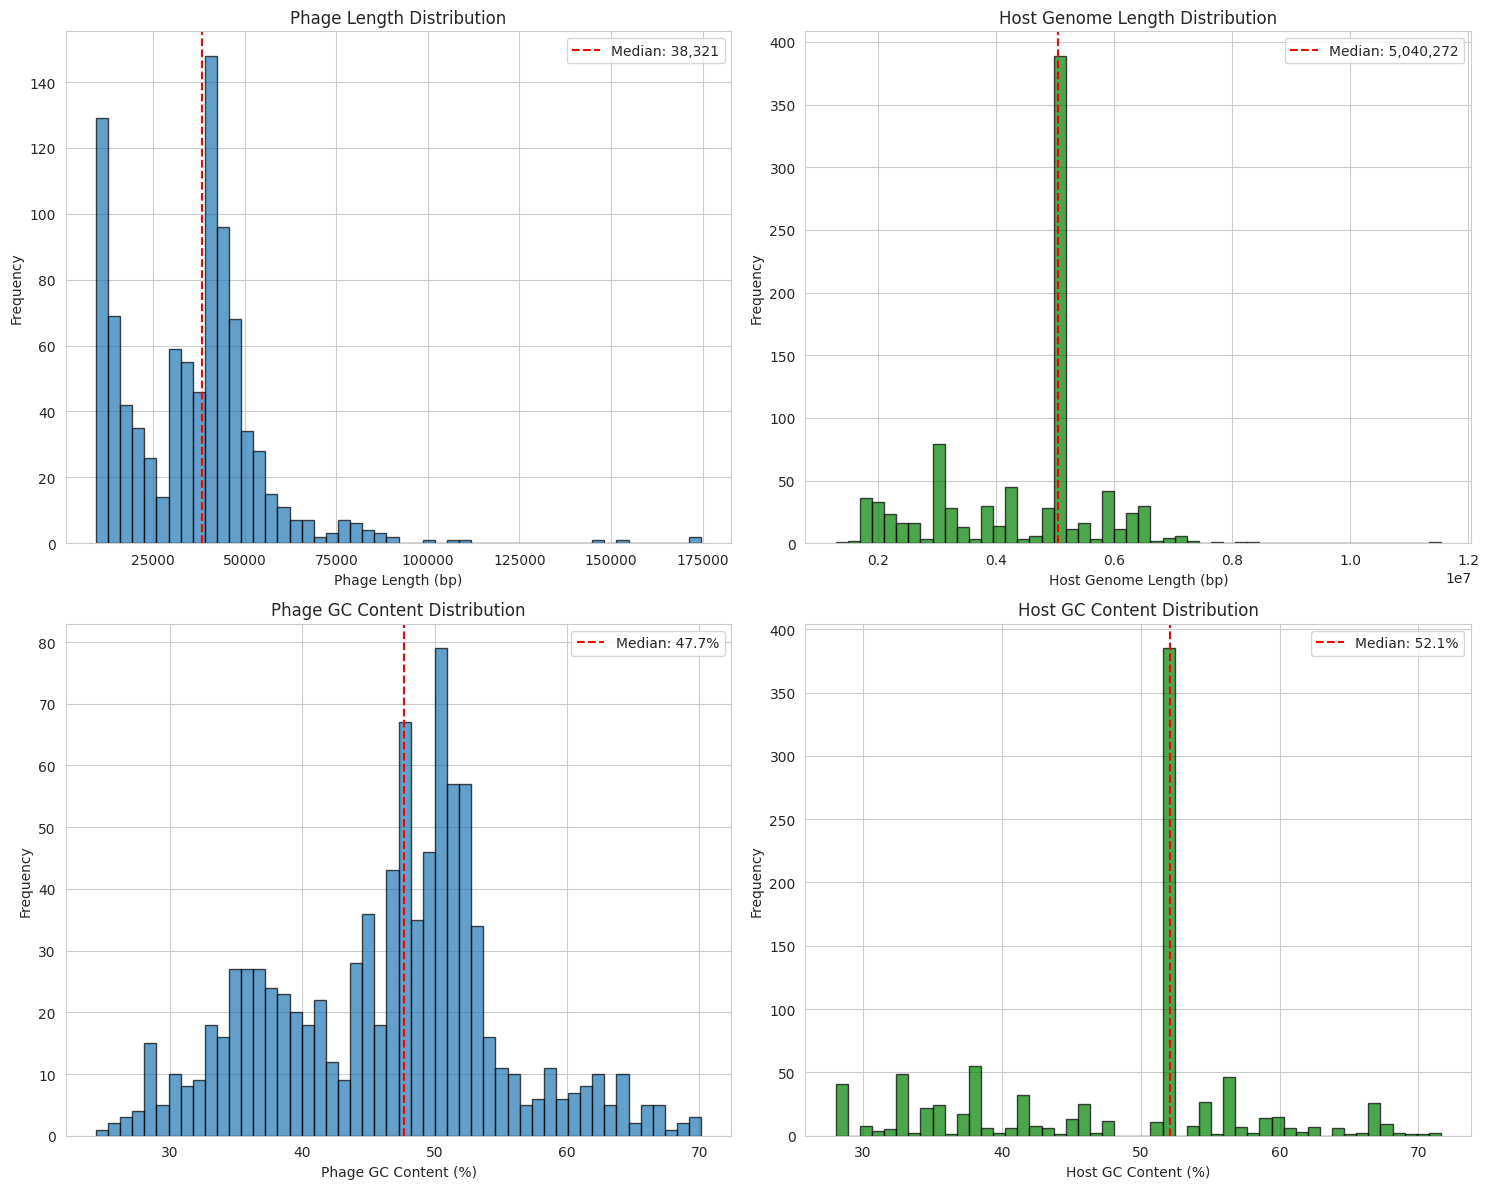

In [7]:
# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Phage length distribution
axes[0, 0].hist(df_clean['Phage_Length'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Phage Length (bp)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Phage Length Distribution')
axes[0, 0].axvline(df_clean['Phage_Length'].median(), color='red', linestyle='--', label=f'Median: {df_clean["Phage_Length"].median():,.0f}')
axes[0, 0].legend()

# Host genome length distribution
axes[0, 1].hist(df_clean['Host_Length'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Host Genome Length (bp)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Host Genome Length Distribution')
axes[0, 1].axvline(df_clean['Host_Length'].median(), color='red', linestyle='--', label=f'Median: {df_clean["Host_Length"].median():,.0f}')
axes[0, 1].legend()

# Phage GC content
axes[1, 0].hist(df_clean['Phage_GC'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Phage GC Content (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Phage GC Content Distribution')
axes[1, 0].axvline(df_clean['Phage_GC'].median(), color='red', linestyle='--', label=f'Median: {df_clean["Phage_GC"].median():.1f}%')
axes[1, 0].legend()

# Host GC content
axes[1, 1].hist(df_clean['Host_GC'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Host GC Content (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Host GC Content Distribution')
axes[1, 1].axvline(df_clean['Host_GC'].median(), color='red', linestyle='--', label=f'Median: {df_clean["Host_GC"].median():.1f}%')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

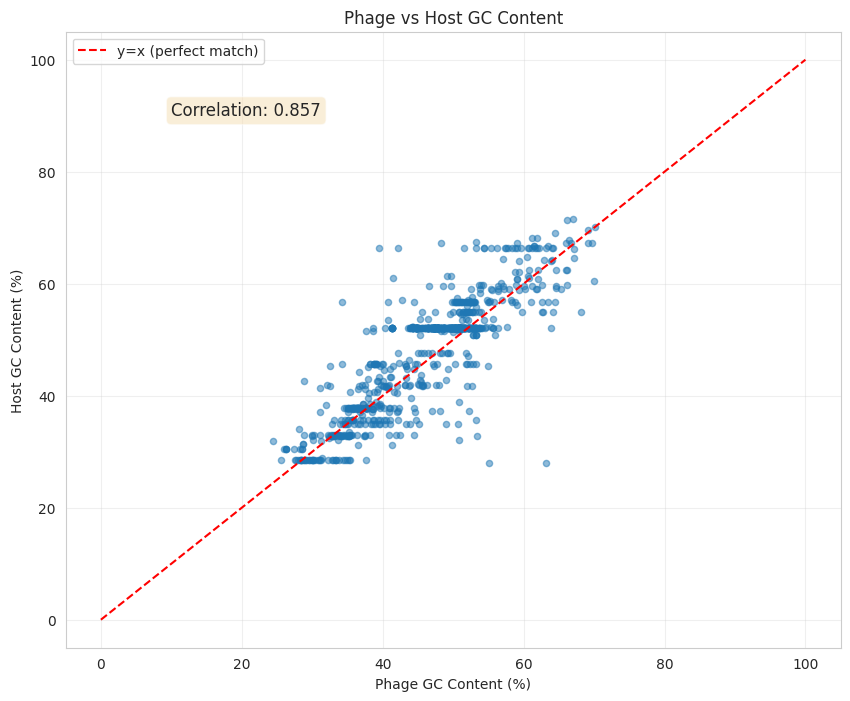

Phage-Host GC Correlation: 0.857


In [8]:
# Phage-Host GC content relationship
plt.figure(figsize=(10, 8))
plt.scatter(df_clean['Phage_GC'], df_clean['Host_GC'], alpha=0.5, s=20)
plt.xlabel('Phage GC Content (%)')
plt.ylabel('Host GC Content (%)')
plt.title('Phage vs Host GC Content')
plt.plot([0, 100], [0, 100], 'r--', label='y=x (perfect match)')
plt.legend()
plt.grid(True, alpha=0.3)

# Calculate correlation
correlation = df_clean['Phage_GC'].corr(df_clean['Host_GC'])
plt.text(10, 90, f'Correlation: {correlation:.3f}', fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

print(f"Phage-Host GC Correlation: {correlation:.3f}")

Top 10 Host Species:
Species_Name
Salmonella enterica         376
Listeria monocytogenes       46
Klebsiella pneumoniae        42
Clostridioides difficile     38
Lawsonia intracellularis     24
Staphylococcus aureus        23
Pseudomonas aeruginosa       23
Bacteroides pyogenes         23
Enterobacter cloacae         21
Streptococcus agalactiae     21
Name: count, dtype: int64


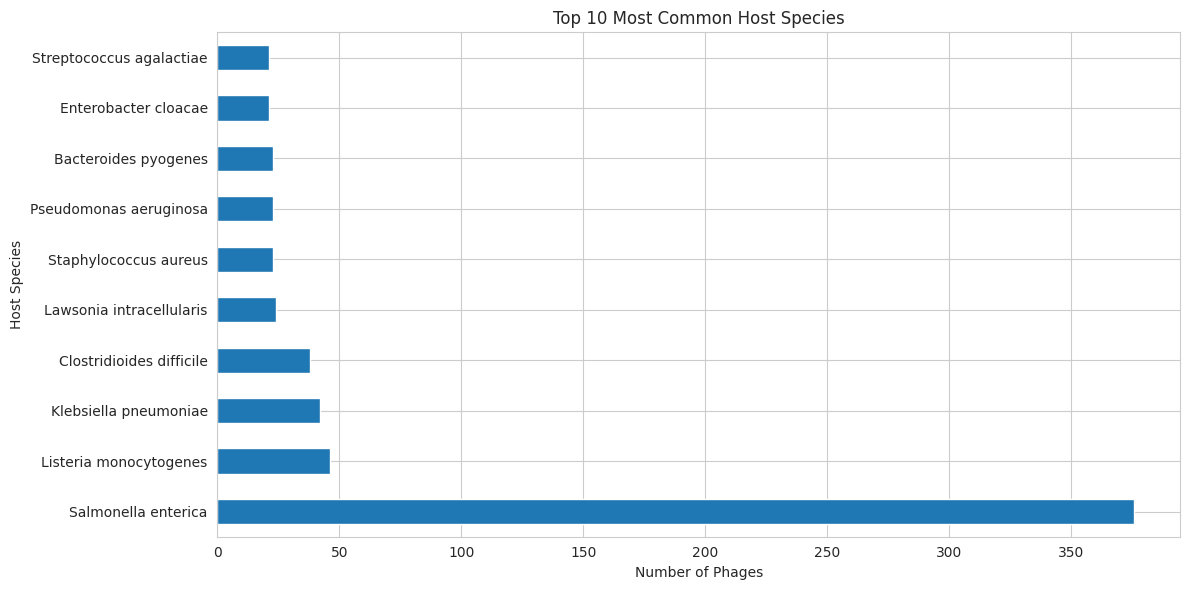

In [9]:
# Host species distribution
print("Top 10 Host Species:")
host_counts = df_clean['Species_Name'].value_counts().head(10)
print(host_counts)

# Plot
plt.figure(figsize=(12, 6))
host_counts.plot(kind='barh')
plt.xlabel('Number of Phages')
plt.ylabel('Host Species')
plt.title('Top 10 Most Common Host Species')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Create features for machine learning from sequence properties.

In [10]:
def engineer_features(df):
    """Create features from phage-host pairs"""
    features = df.copy()
    
    # GC content features
    features['GC_Difference'] = abs(features['Phage_GC'] - features['Host_GC'])
    features['GC_Ratio'] = features['Phage_GC'] / (features['Host_GC'] + 1e-6)
    features['GC_Sum'] = features['Phage_GC'] + features['Host_GC']
    
    # Length features
    features['Length_Ratio'] = features['Phage_Length'] / (features['Host_Length'] + 1)
    features['Log_Phage_Length'] = np.log10(features['Phage_Length'] + 1)
    features['Log_Host_Length'] = np.log10(features['Host_Length'] + 1)
    
    # Interaction features
    features['GC_x_Length_Ratio'] = features['GC_Ratio'] * features['Length_Ratio']
    
    return features

# Apply feature engineering
df_features = engineer_features(df_clean)

print("Engineered features:")
print(df_features[['GC_Difference', 'GC_Ratio', 'Length_Ratio', 'GC_x_Length_Ratio']].describe())

Engineered features:
       GC_Difference    GC_Ratio  Length_Ratio  GC_x_Length_Ratio
count     923.000000  923.000000         923.0              923.0
mean        3.893348    0.972870       0.00913           0.008949
std         3.627911    0.117274      0.007261           0.007669
min         0.002965    0.594053      0.001529           0.001102
25%         1.396961    0.912153      0.004522           0.004381
50%         2.925437    0.963145      0.008012           0.007458
75%         5.204824    1.011587      0.011136           0.010959
max        35.068812    2.250225      0.102787           0.130663


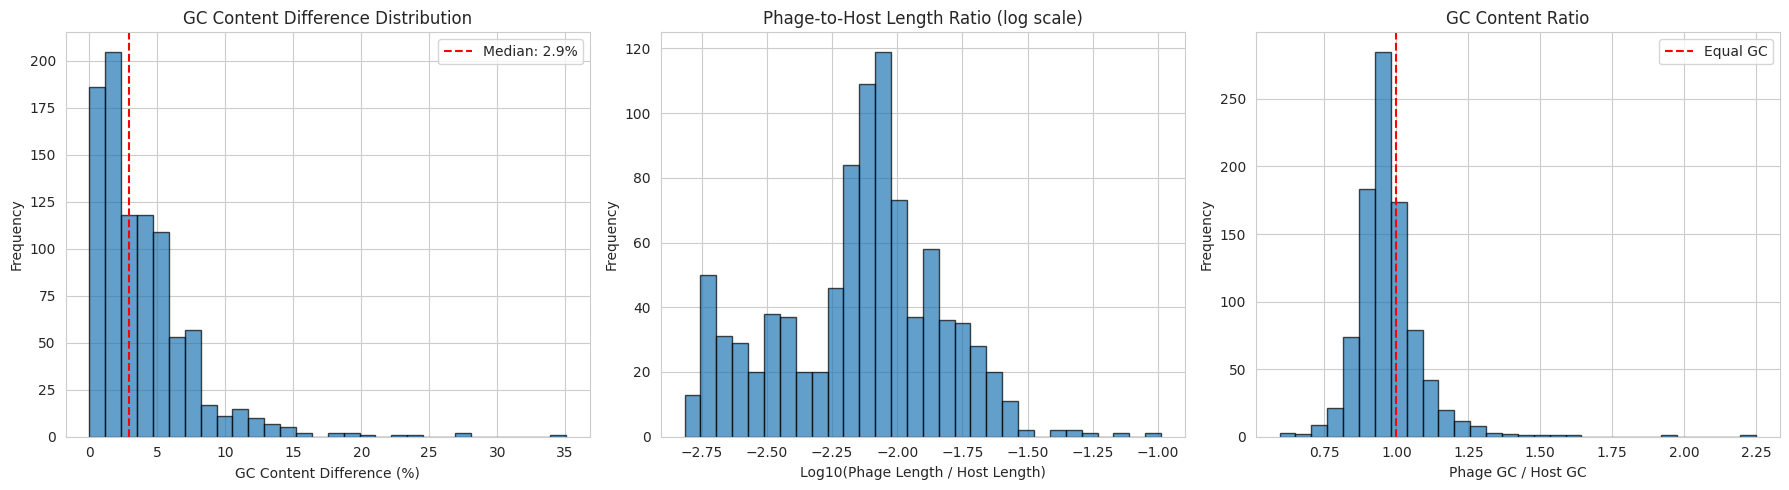

In [11]:
# Visualize key features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GC Difference
axes[0].hist(df_features['GC_Difference'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('GC Content Difference (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('GC Content Difference Distribution')
axes[0].axvline(df_features['GC_Difference'].median(), color='red', linestyle='--', 
                label=f'Median: {df_features["GC_Difference"].median():.1f}%')
axes[0].legend()

# Length Ratio (log scale)
axes[1].hist(np.log10(df_features['Length_Ratio']), bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log10(Phage Length / Host Length)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Phage-to-Host Length Ratio (log scale)')

# GC Ratio
axes[2].hist(df_features['GC_Ratio'], bins=30, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Phage GC / Host GC')
axes[2].set_ylabel('Frequency')
axes[2].set_title('GC Content Ratio')
axes[2].axvline(1.0, color='red', linestyle='--', label='Equal GC')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Generate Negative Examples

Create non-interacting phage-host pairs for training a binary classifier.

In [12]:
# Initialize negative example generator
neg_gen = NegativeExampleGenerator(retriever)

print("✅ NegativeExampleGenerator initialized")

2026-02-20 08:06:11,886 - INFO - 📊 Cached 873,718 phages and 5,525 hosts
2026-02-20 08:06:11,888 - INFO - ✅ NegativeExampleGenerator initialized
2026-02-20 08:06:11,890 - INFO -    Available phages: 873,718
2026-02-20 08:06:11,892 - INFO -    Available hosts: 5,525


✅ NegativeExampleGenerator initialized


In [13]:
# Generate random negatives (1:1 ratio)
print("🎲 Generating random negative examples...")
negatives_random = neg_gen.generate_random_negatives(positive_pairs, ratio=1.0)

print(f"✅ Generated {len(negatives_random):,} random negatives")
negatives_random.head()

2026-02-20 08:06:11,907 - INFO - 🎲 Generating random negative examples...
2026-02-20 08:06:11,909 - INFO -    Target: 923 negatives from 923 positives
2026-02-20 08:06:11,911 - INFO -    Positive set size: 923


🎲 Generating random negative examples...


2026-02-20 08:06:14,317 - INFO -    Generated 100/923 negatives...
2026-02-20 08:06:16,432 - INFO -    Generated 200/923 negatives...
2026-02-20 08:06:18,550 - INFO -    Generated 300/923 negatives...
2026-02-20 08:06:20,664 - INFO -    Generated 400/923 negatives...
2026-02-20 08:06:23,051 - INFO -    Generated 500/923 negatives...
2026-02-20 08:06:25,148 - INFO -    Generated 600/923 negatives...
2026-02-20 08:06:27,236 - INFO -    Generated 700/923 negatives...
2026-02-20 08:06:29,323 - INFO -    Generated 800/923 negatives...
2026-02-20 08:06:31,413 - INFO -    Generated 900/923 negatives...
2026-02-20 08:06:31,902 - INFO - ✅ Generated 923 random negative pairs


✅ Generated 923 random negatives


,Phage_ID,Host_ID,Phage_GC,Phage_Length,Host_GC,Host_Length,Label
0,IMGVR_UViG_2547132099_000007|2547132099|254714...,GCF_031081985_1,34.662800,188271,62.60,3529875,0
1,Station65_DCM_ALL_assembly_NODE_827_length_254...,GCF_977949085_1,53.883286,25481,60.42,2270338,0
2,IMGVR_UViG_3300045988_145248|3300045988|Ga0495...,GCF_042933535_1,36.666500,40102,42.87,5390436,0
3,IMGVR_UViG_2887284248_000001|2887284248|288728...,GCF_900638305_1,34.203728,32131,47.62,2404857,0
4,Station168_SUR_ALL_assembly_NODE_5443_length_1...,GCF_053629635_1,36.483434,15936,72.01,8451009,0


In [14]:
# Generate GC-based negatives
print("🧬 Generating GC-based negative examples...")
negatives_gc = neg_gen.generate_gc_based_negatives(
    positive_pairs, 
    ratio=0.5,
    min_gc_difference=20.0
)

print(f"✅ Generated {len(negatives_gc):,} GC-based negatives")
print(f"Mean GC difference: {negatives_gc['GC_Difference'].mean():.1f}%")

2026-02-20 08:06:31,929 - INFO - 🧬 Generating GC-based negative examples (min diff: 20.0%)...


🧬 Generating GC-based negative examples...


2026-02-20 08:06:38,827 - INFO -    Generated 100/461 negatives...
2026-02-20 08:06:38,853 - INFO -    Generated 100/461 negatives...
2026-02-20 08:06:38,876 - INFO -    Generated 100/461 negatives...
2026-02-20 08:06:38,899 - INFO -    Generated 100/461 negatives...
2026-02-20 08:06:45,642 - INFO -    Generated 200/461 negatives...
2026-02-20 08:06:53,239 - INFO -    Generated 300/461 negatives...
2026-02-20 08:06:53,262 - INFO -    Generated 300/461 negatives...
2026-02-20 08:06:53,284 - INFO -    Generated 300/461 negatives...
2026-02-20 08:06:53,306 - INFO -    Generated 300/461 negatives...
2026-02-20 08:06:53,327 - INFO -    Generated 300/461 negatives...
2026-02-20 08:06:53,349 - INFO -    Generated 300/461 negatives...
2026-02-20 08:06:53,370 - INFO -    Generated 300/461 negatives...
2026-02-20 08:07:00,745 - INFO -    Generated 400/461 negatives...
2026-02-20 08:07:00,767 - INFO -    Generated 400/461 negatives...
2026-02-20 08:07:04,508 - INFO - ✅ Generated 461 GC-based nega

✅ Generated 461 GC-based negatives
Mean GC difference: 27.4%


## 7. Create Balanced Dataset

Combine positive and negative examples into a balanced training dataset.

In [15]:
# Generate balanced dataset with mixed strategy
print("🔨 Creating balanced dataset...")
dataset = neg_gen.generate_balanced_dataset(
    positive_pairs=positive_pairs,
    strategy='mixed',
    positive_ratio=0.5
)

print(f"\n✅ Dataset created:")
print(f"   Total samples: {len(dataset):,}")
print(f"   Positives: {(dataset['Label'] == 1).sum():,}")
print(f"   Negatives: {(dataset['Label'] == 0).sum():,}")

dataset.head()

2026-02-20 08:07:04,529 - INFO - 🔨 Generating balanced dataset (strategy: mixed, ratio: 0.5)...
2026-02-20 08:07:04,533 - INFO -    Target: 923 positives, 923 negatives
2026-02-20 08:07:04,535 - INFO - 🎲 Generating random negative examples...
2026-02-20 08:07:04,536 - INFO -    Target: 307 negatives from 923 positives
2026-02-20 08:07:04,537 - INFO -    Positive set size: 923


🔨 Creating balanced dataset...


2026-02-20 08:07:06,625 - INFO -    Generated 100/307 negatives...
2026-02-20 08:07:08,705 - INFO -    Generated 200/307 negatives...
2026-02-20 08:07:11,091 - INFO -    Generated 300/307 negatives...
2026-02-20 08:07:11,240 - INFO - ✅ Generated 307 random negative pairs
2026-02-20 08:07:11,241 - INFO - 🧬 Generating GC-based negative examples (min diff: 20.0%)...
2026-02-20 08:07:18,321 - INFO -    Generated 100/307 negatives...
2026-02-20 08:07:26,014 - INFO -    Generated 200/307 negatives...
2026-02-20 08:07:33,882 - INFO -    Generated 300/307 negatives...
2026-02-20 08:07:33,904 - INFO -    Generated 300/307 negatives...
2026-02-20 08:07:33,926 - INFO -    Generated 300/307 negatives...
2026-02-20 08:07:34,203 - INFO - ✅ Generated 307 GC-based negative pairs
2026-02-20 08:07:34,205 - INFO -    Mean GC difference: 27.0%
2026-02-20 08:07:34,206 - INFO - 🌳 Generating taxonomy-based negative examples...
2026-02-20 08:07:35,536 - INFO -    Excluding 141 species from negatives
2026-02-2


✅ Dataset created:
   Total samples: 1,844
   Positives: 923
   Negatives: 921


,Phage_ID,Host_ID,Phage_Source,Phage_Length,Phage_GC,Phage_Taxonomy,Phage_Completeness,Phage_Lifestyle,Phage_Cluster,Phage_Subcluster,Species_Name,Host_Assembly_Level,Host_Length,Host_GC,Host_RefSeq_Category,Phage_Sequence,Host_Sequence,Label,GC_Difference,Host_Species
0,uvig_205090,GCF_004564235_1,NaN,99007,33.426929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5049922,49.88,NaN,NaN,NaN,0,NaN,Cohnella luojiensis
1,TemPhD_cluster_24174,GCF_048270305_1,NaN,50396,49.212239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2658303,33.08,NaN,NaN,NaN,0,NaN,NaN
2,TemPhD_cluster_40442,GCF_051046885_1,TemPhD,47057,50.874471,Caudovirales,Medium-quality,temperate,cluster_249338,subcluster_313262,Enterobacter cloacae,Complete Genome,4935288,54.92,na,TTAGCGCCTTCCATCAGACGTTCAAAGTCATAGGTGACGGTTTTCG...,ATGTCGTGAAATTAAGAAACCGAAACCGGACAACGTCGGGCGCTGA...,1,NaN,NaN
3,IMGVR_UViG_3300045988_127409|3300045988|Ga0495...,GCF_001434835_1,NaN,59235,29.786444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2918319,51.59,NaN,NaN,NaN,0,21.803556,NaN
4,MGV-GENOME-0258093,GCF_900104475_1,NaN,38119,41.897741,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5038150,68.42,NaN,NaN,NaN,0,26.522259,NaN


In [16]:
# Apply feature engineering to full dataset
dataset_clean = dataset.dropna(subset=['Phage_GC', 'Host_GC', 'Phage_Length', 'Host_Length'])
dataset_features = engineer_features(dataset_clean)

print(f"Dataset with features: {len(dataset_features):,} samples")
print(f"Feature columns: {[col for col in dataset_features.columns if col not in positive_pairs.columns]}")

Dataset with features: 1,844 samples
Feature columns: ['GC_Difference', 'Host_Species', 'GC_Ratio', 'GC_Sum', 'Length_Ratio', 'Log_Phage_Length', 'Log_Host_Length', 'GC_x_Length_Ratio']


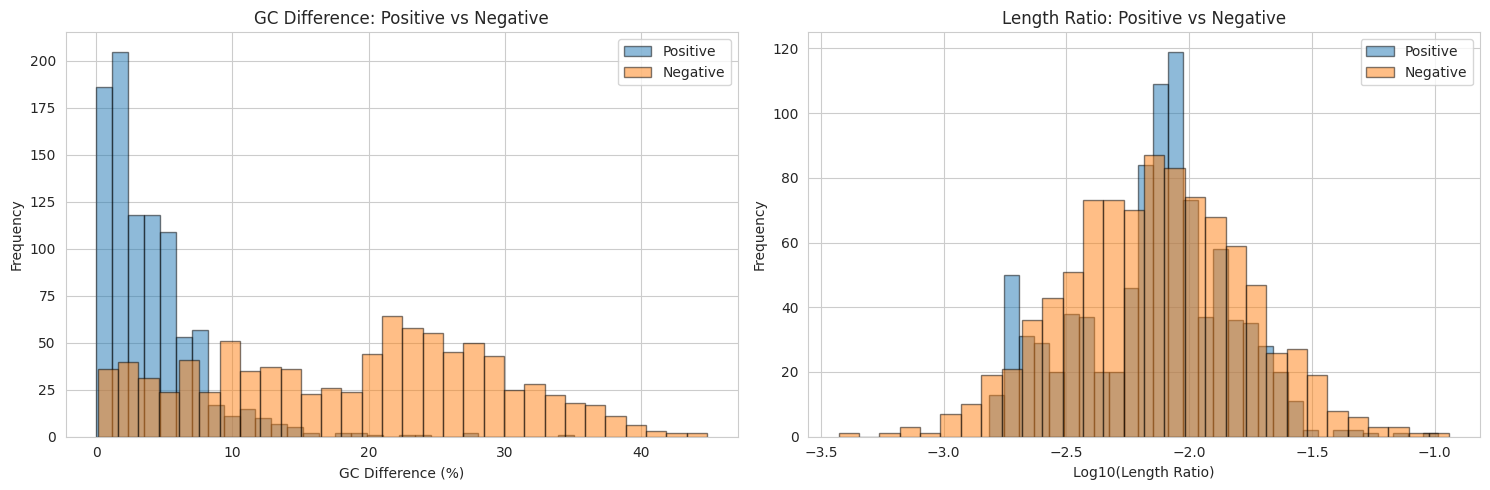

In [17]:
# Compare positive and negative distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# GC Difference comparison
positive_data = dataset_features[dataset_features['Label'] == 1]['GC_Difference']
negative_data = dataset_features[dataset_features['Label'] == 0]['GC_Difference']

axes[0].hist(positive_data, bins=30, alpha=0.5, label='Positive', edgecolor='black')
axes[0].hist(negative_data, bins=30, alpha=0.5, label='Negative', edgecolor='black')
axes[0].set_xlabel('GC Difference (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('GC Difference: Positive vs Negative')
axes[0].legend()

# Length Ratio comparison (log scale)
positive_ratio = dataset_features[dataset_features['Label'] == 1]['Length_Ratio']
negative_ratio = dataset_features[dataset_features['Label'] == 0]['Length_Ratio']

axes[1].hist(np.log10(positive_ratio), bins=30, alpha=0.5, label='Positive', edgecolor='black')
axes[1].hist(np.log10(negative_ratio), bins=30, alpha=0.5, label='Negative', edgecolor='black')
axes[1].set_xlabel('Log10(Length Ratio)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Length Ratio: Positive vs Negative')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Save Datasets

Export datasets for use in ML training.

**Note:** Datasets are saved to `/workspace/ml_datasets/` which is local to the analysis container.

**To access exported files:**
- **Inside the container:** Files are available at `/workspace/ml_datasets/`
- **From your host machine:** 
  - Use `docker cp` to copy files from the container to your host:
    ```bash
    docker cp pbi-analysis:/workspace/ml_datasets/phage_host_features.csv ./
    ```
  - Or mount `/workspace` as a volume when starting the container (see docker-compose.yml)


In [18]:
# Define feature columns for ML
feature_cols = [
    'Phage_Length', 'Phage_GC',
    'Host_Length', 'Host_GC',
    'GC_Difference', 'GC_Ratio', 'GC_Sum',
    'Length_Ratio', 'Log_Phage_Length', 'Log_Host_Length',
    'GC_x_Length_Ratio'
]

# Create features-only dataset
ml_dataset = dataset_features[feature_cols + ['Label']].copy()

print(f"ML Dataset: {len(ml_dataset):,} samples x {len(feature_cols)} features")
print(f"\nFeature columns:")
for col in feature_cols:
    print(f"  - {col}")

ML Dataset: 1,844 samples x 11 features

Feature columns:
  - Phage_Length
  - Phage_GC
  - Host_Length
  - Host_GC
  - GC_Difference
  - GC_Ratio
  - GC_Sum
  - Length_Ratio
  - Log_Phage_Length
  - Log_Host_Length
  - GC_x_Length_Ratio


In [19]:
# Save datasets
# Use /workspace for writable storage in the analysis container
output_dir = Path('/workspace/ml_datasets')
output_dir.mkdir(parents=True, exist_ok=True)

# Save full dataset with sequences (parquet for efficiency)
dataset_features.to_parquet(output_dir / 'phage_host_dataset_full.parquet', index=False)
print(f"✅ Saved: {output_dir / 'phage_host_dataset_full.parquet'}")

# Save features-only dataset (CSV for compatibility)
ml_dataset.to_csv(output_dir / 'phage_host_features.csv', index=False)
print(f"✅ Saved: {output_dir / 'phage_host_features.csv'}")

# Save positive pairs only
positive_pairs.to_csv(output_dir / 'positive_pairs.csv', index=False)
print(f"✅ Saved: {output_dir / 'positive_pairs.csv'}")

✅ Saved: /workspace/ml_datasets/phage_host_dataset_full.parquet
✅ Saved: /workspace/ml_datasets/phage_host_features.csv
✅ Saved: /workspace/ml_datasets/positive_pairs.csv


## 9. Baseline ML Model

Train a simple Random Forest classifier as a baseline.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

print("✅ ML libraries imported")

✅ ML libraries imported


In [21]:
# Prepare data
X = ml_dataset[feature_cols]
y = ml_dataset['Label']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"\nClass balance (train):")
print(y_train.value_counts())

Training set: 1,475 samples
Test set: 369 samples

Class balance (train):
Label
1    738
0    737
Name: count, dtype: int64


In [22]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features standardized")

✅ Features standardized


In [23]:
# Train Random Forest
print("🌲 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
print("✅ Model trained")

🌲 Training Random Forest...
✅ Model trained


In [24]:
# Evaluate on test set
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# ROC-AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc_score:.3f}")

📊 Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.89      0.91       184
    Positive       0.90      0.92      0.91       185

    accuracy                           0.91       369
   macro avg       0.91      0.91      0.91       369
weighted avg       0.91      0.91      0.91       369


ROC-AUC Score: 0.971


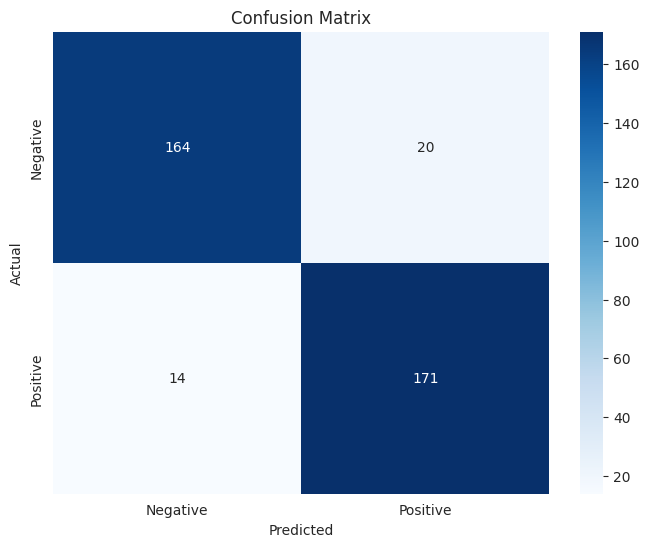

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

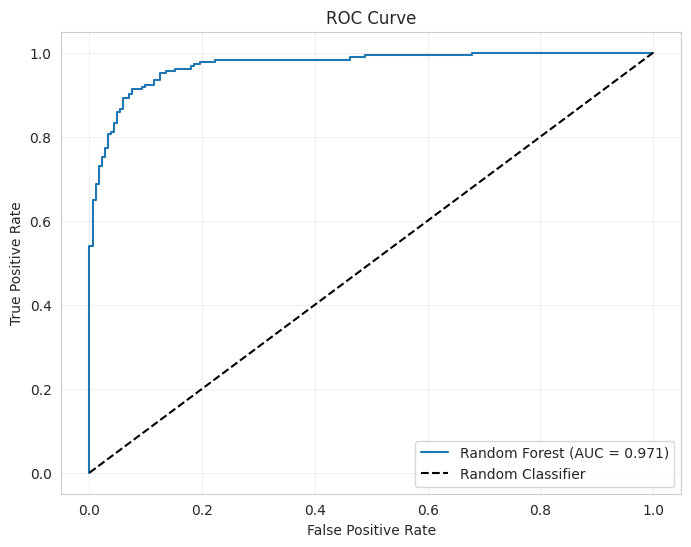

In [26]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

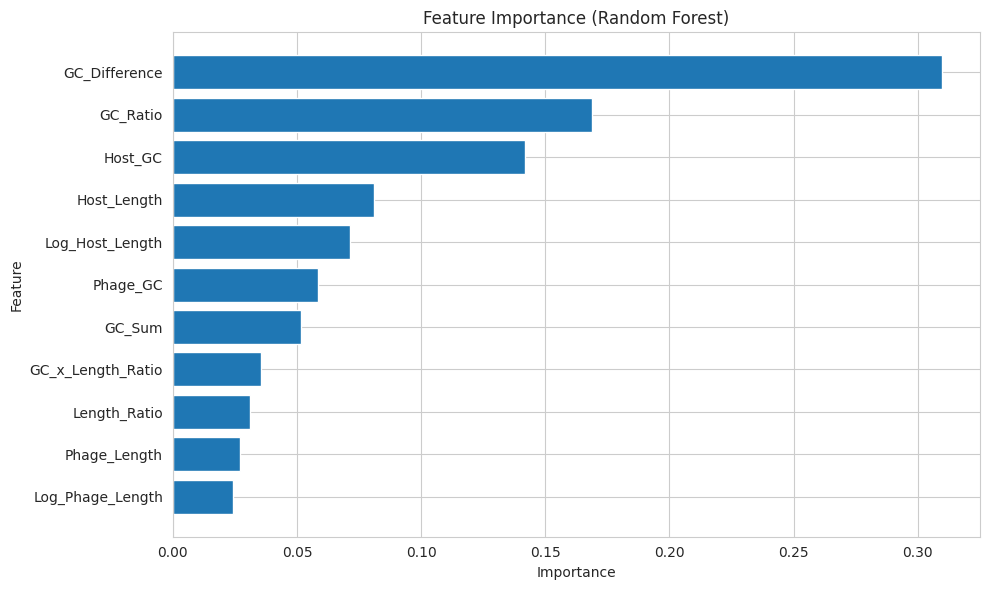


Top 5 Most Important Features:
           Feature  Importance
4    GC_Difference    0.309566
5         GC_Ratio    0.168612
3          Host_GC    0.141865
2      Host_Length    0.081037
9  Log_Host_Length    0.071199


In [27]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

## 10. Next Steps

### Advanced ML Approaches

1. **Sequence-based Features**
   - K-mer frequencies (DNA/protein)
   - Codon usage patterns
   - Protein domain annotations
   - CRISPR spacer matches

2. **Deep Learning**
   - CNN/LSTM for sequence modeling
   - Transformer models (DNA-BERT, etc.)
   - Graph neural networks (phage-host networks)

3. **Advanced Models**
   - Gradient Boosting (XGBoost, LightGBM)
   - Ensemble methods
   - Neural networks

4. **Feature Engineering**
   - Taxonomic embeddings
   - Host receptor proteins
   - Phage structural proteins
   - Lifestyle-specific features

### Use Cases

- **Host Range Prediction**: Predict which hosts a phage can infect
- **Therapeutic Candidate Selection**: Identify phages for specific bacterial infections
- **Lifestyle Classification**: Predict lytic vs lysogenic based on sequences
- **Protein Function Prediction**: Classify protein functions

### Resources

- [PBI Documentation](https://thibaultschowing.github.io/PBI/)
- [Machine Learning Guide](https://thibaultschowing.github.io/PBI/guides/machine-learning/)
- [Database Schema](https://thibaultschowing.github.io/PBI/database/schema/)

In [28]:
# Cleanup
retriever.close()
print("✅ Database connection closed")

2026-02-20 08:09:51,718 - INFO - 🔒 Database connection closed


✅ Database connection closed
